   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 no

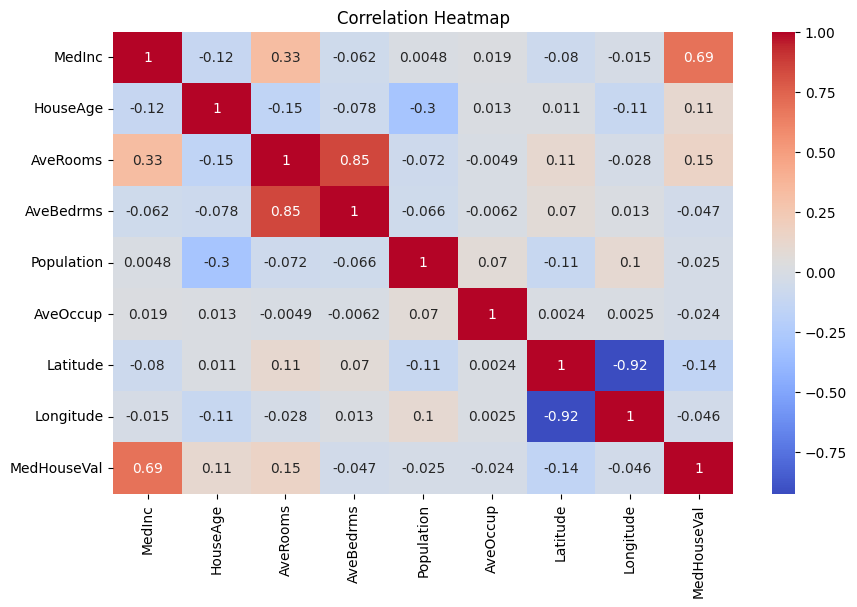

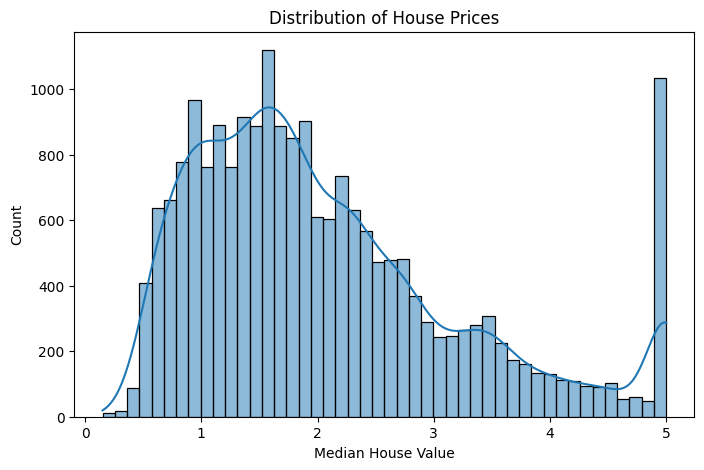

Model Evaluation Results
MAE: 0.5332001304956555
RMSE: 0.7455813830127763
R² Score: 0.575787706032451


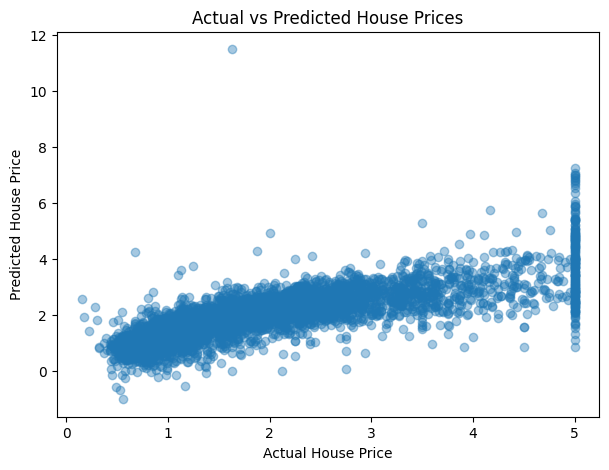

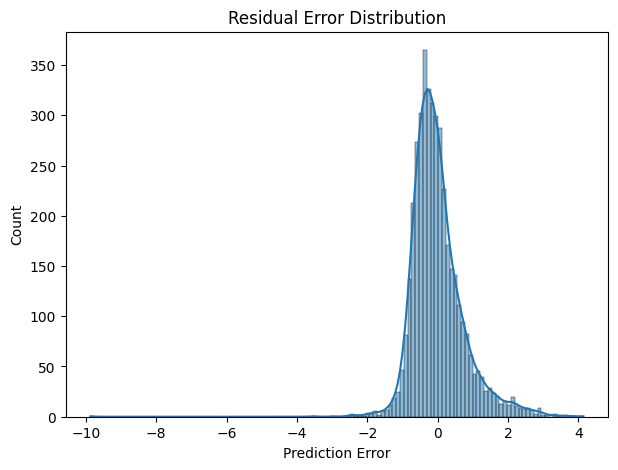

Model saved successfully!


In [3]:
# Task 1: House Price Prediction using Linear Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Display first 5 rows
print(df.head())

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Distribution of target variable
plt.figure(figsize=(8, 5))
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

# Split features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

# Save model
joblib.dump(model, "linear_regression_house_price_model.pkl")

print("Model saved successfully!")